/opt/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(


N= 2, τ=0.6822, Eb=1.058141, Ergotropy=1.020168, erg/Eb=0.964113651149, Variance=5.7360130333e-01, Third Moment=2.2200682298e+00
N= 3, τ=0.5807, Eb=1.683140, Ergotropy=1.636665, erg/Eb=0.972388170139, Variance=8.8272458818e-01, Third Moment=7.7093750915e+00
N= 4, τ=0.5158, Eb=2.323216, Ergotropy=2.270698, erg/Eb=0.977394390424, Variance=1.1937538485e+00, Third Moment=1.8389482861e+01
N= 5, τ=0.4696, Eb=2.973274, Ergotropy=2.916091, erg/Eb=0.980767557910, Variance=1.5059273173e+00, Third Moment=3.6059107399e+01
N= 6, τ=0.4344, Eb=3.629995, Ergotropy=3.569077, erg/Eb=0.983217925261, Variance=1.8187600085e+00, Third Moment=6.2548858851e+01
N= 7, τ=0.4065, Eb=4.292903, Ergotropy=4.228811, erg/Eb=0.985070184249, Variance=2.1321818007e+00, Third Moment=9.9794715938e+01
N= 8, τ=0.3835, Eb=4.959030, Ergotropy=4.892298, erg/Eb=0.986543280721, Variance=2.4458189472e+00, Third Moment=1.4961657819e+02
N= 9, τ=0.3642, Eb=5.629109, Ergotropy=5.560055, erg/Eb=0.987732639319, Variance=2.7597658646e+00

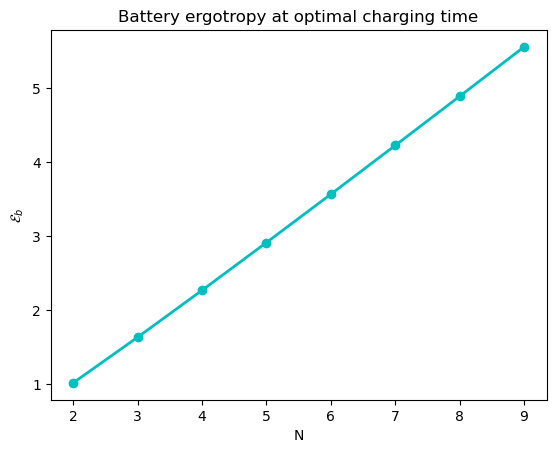

In [1]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt

############
# parameters
############

N_arr = np.arange(2, 10, 1)
nmax = 80
ω = 1.0
ω0 = 1.0
g = 1.0
tlist = np.arange(0.01, 2*np.pi, 0.0001)

#############################
# Tavis–Cummings Hamiltonian
#############################

def tavis_cummings(N, nmax, ω, ω0, g):

    a  = qt.destroy(nmax)
    Ic = qt.qeye(nmax)

    sp, sm, sz = qt.sigmap(), qt.sigmam(), qt.sigmaz()

    def embed(op, i):
        ops = [qt.qeye(2)]*N
        ops[i] = op
        return qt.tensor(ops)

    Sp = sum(embed(sp, i) for i in range(N))
    Sm = Sp.dag()
    Sz = 0.5 * sum(embed(sz, i) for i in range(N))

    IB = qt.tensor([qt.qeye(2)]*N)
    HB = Sz + 0.5 * N * IB

    H = (ω * qt.tensor(a.dag()*a, IB) + ω0 * qt.tensor(Ic, HB) + g * (qt.tensor(a, Sp) + qt.tensor(a.dag(), Sm)))
    return H, HB

##################
# Initial state
##################

def initial_state(N, nmax, state):

    if state == "coherent":
        psiA = qt.coherent(nmax, np.sqrt(N))
    elif state == "fock":
        psiA = qt.basis(nmax, N)

    psiB = qt.tensor([qt.basis(2, 1) for _ in range(N)])
    return qt.tensor(psiA, psiB)

#########################################
# optimal charging time τ (maximum power)
#########################################

τ_list = []

for N in N_arr:
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    HB_full = qt.tensor(qt.qeye(nmax), HB)
    psi0 = initial_state(N, nmax, "coherent")

    opts = qt.Options(atol=1e-16, rtol=1e-14)        ## ODE solver options
    res = qt.sesolve(H, psi0, tlist, e_ops=HB_full, options=opts)
    EB = np.array(res.expect[0])
    power = EB / tlist

    τ_list.append(tlist[np.argmax(power)])

###########################################
# Calculation of ergotropy and fluctuations
###########################################

E_ratio, E_ergo, E_var, E_momen3, F_ratio, FE_ratio = [], [], [], [], [], []

for i, N in enumerate(N_arr):

    τ = τ_list[i]
    
    H, HB = tavis_cummings(N, nmax, ω, ω0, g)
    
    psi0 = initial_state(N, nmax, "coherent")

    res = qt.sesolve(H, psi0, [0, τ], options=opts)
    
    rho_b = res.states[-1].ptrace(list(range(1, N+1)))

    E_B = qt.expect(HB, rho_b)
    
    r_vals, r_vecs = rho_b.eigenstates()

    # Clip numerical noise to prevent negative probabilities
    r_vals = np.maximum(r_vals, 0) 
    # Renormalize 
    r_vals = r_vals / np.sum(r_vals)
    
    idx = np.argsort(r_vals)[::-1]
    r_vals = r_vals[idx]
    r_vecs = [r_vecs[i] for i in idx]
    
    # Passive Hamiltonian constructed in the passive state's eigenbasis
    
    e_vals, e_vecs = HB.eigenstates()
    
    H_passive = sum(e_vals[i] * r_vecs[i] * r_vecs[i].dag() for i in range(len(e_vals)))

    # Ergotropy operator defined w.r.t. passive Hamiltonian
    
    E_op = HB - H_passive
    
    E_B = qt.expect(HB, rho_b)
    
    E_erg = qt.expect(E_op, rho_b)

    ΔE2 = qt.expect(E_op**2, rho_b) - E_erg**2
    
    ΔE = np.sqrt(qt.expect(E_op**2, rho_b) - E_erg**2)

    E_erg3 = qt.expect(E_op**3, rho_b)

    Ratio = E_erg / E_B
    
    E_ergo.append(E_erg)

    E_var.append(ΔE2)

    E_momen3.append(E_erg3)
    
    E_ratio.append(Ratio)
    
    F_ratio.append(ΔE / E_erg)

    FE_ratio.append(ΔE / E_B)

    print(f"N={N:2d}, τ={τ:.4f}, Eb={E_B:.6f}, Ergotropy={E_erg:.6f}, erg/Eb={Ratio:.12f}, Variance={ΔE2:.10e}, Third Moment={E_erg3:.10e}")


###############################################################
# Plot of battery ergotropy at optimal charging for different N 
###############################################################

plt.plot(N_arr, E_ergo, 'o-', color='c', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b$")
plt.title("Battery ergotropy at optimal charging time")
# plt.savefig("OP1")
plt.show()

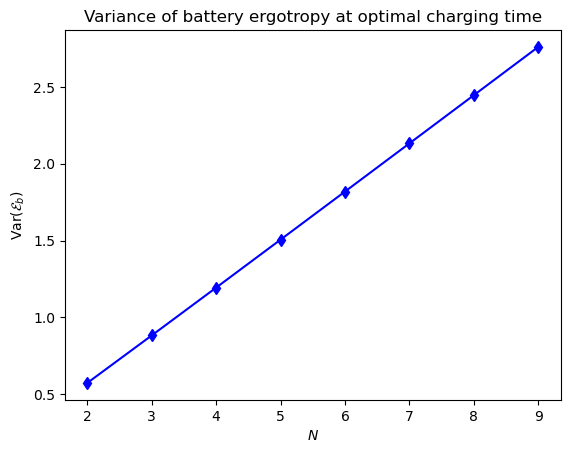

In [2]:
###########################################################################
# Plot of variance of battery ergotropy at optimal charging for different N 
###########################################################################

plt.figure()
plt.plot(N_arr, E_var, 'd-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\mathrm{Var}(\mathcal{E}_b)$")
plt.title("Variance of battery ergotropy at optimal charging time")
# plt.savefig("OP2")
plt.show()

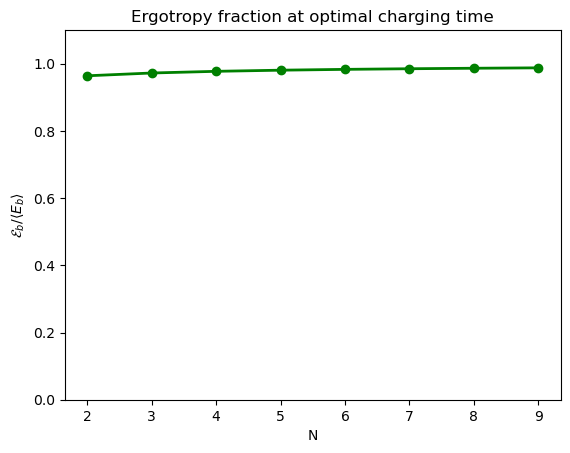

In [3]:
#############################################################
# Plot ergotropy fraction as a function of g for different N 
############################################################
    
plt.plot(N_arr, E_ratio, 'o-', color='g', linewidth=2)
plt.xlabel("N")
plt.ylabel(r"$\mathcal{E}_b / \langle E_b \rangle$")
plt.ylim(0,1.1)
plt.title("Ergotropy fraction at optimal charging time")
# plt.savefig("OP3")
plt.show()

N= 2, τ=0.6822, Relative Fluctuation =0.742391876427, Relative Fluctuation with Eb =0.715750142565
N= 3, τ=0.5807, Relative Fluctuation =0.574053974810, Relative Fluctuation with Eb =0.558203294127
N= 4, τ=0.5158, Relative Fluctuation =0.481169352761, Relative Fluctuation with Eb =0.470292226233
N= 5, τ=0.4696, Relative Fluctuation =0.420824435350, Relative Fluctuation with Eb =0.412730953767
N= 6, τ=0.4344, Relative Fluctuation =0.377860794417, Relative Fluctuation with Eb =0.371519506324
N= 7, τ=0.4065, Relative Fluctuation =0.345297843623, Relative Fluctuation with Eb =0.340142610438
N= 8, τ=0.3835, Relative Fluctuation =0.319668080981, Relative Fluctuation with Eb =0.315366397353
N= 9, τ=0.3642, Relative Fluctuation =0.298783806981, Relative Fluctuation with Eb =0.295118518255


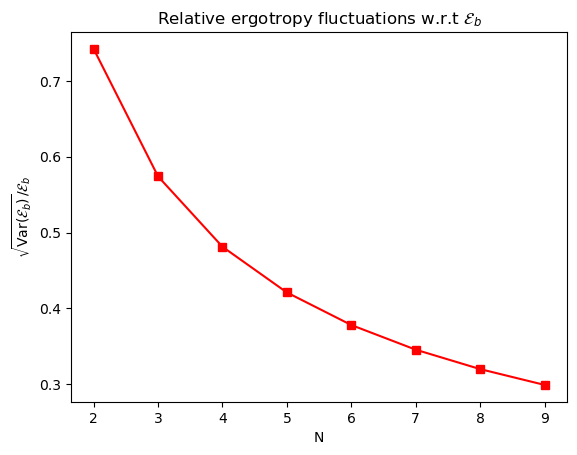

In [4]:
for idx, N in enumerate(N_arr):
    print(f"N={N:2d}, τ={τ_list[idx]:.4f}, Relative Fluctuation ={F_ratio[idx]:.12f}, Relative Fluctuation with Eb ={FE_ratio[idx]:.12f}")


######################################################
# Plot fluctuations as a function of g for different N 
######################################################

plt.plot(N_arr, F_ratio, 's-', color='r')
plt.xlabel("N")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/\mathcal{E}_b$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\mathcal{E}_b$")
# plt.savefig("OP4")
plt.show()

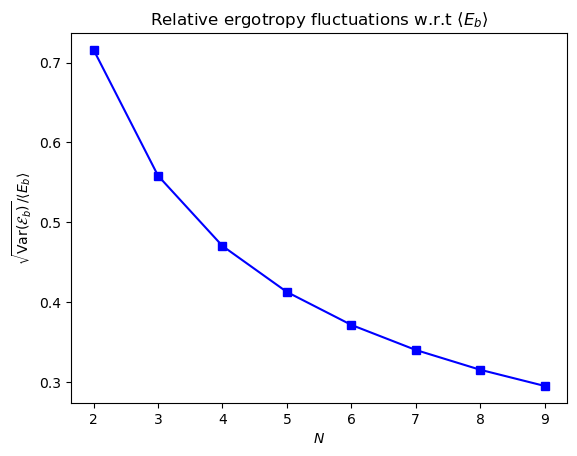

In [5]:
##########################################################################
# Plot fluctuations w.r.t battery energy as function of g for different N 
##########################################################################

plt.figure()
plt.plot(N_arr, FE_ratio, 's-', color='b')
plt.xlabel(r"$N$")
plt.ylabel(r"$\sqrt{\mathrm{Var}(\mathcal{E}_b)}/ \langle E_b \rangle$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
# plt.savefig("OP5")
plt.show()

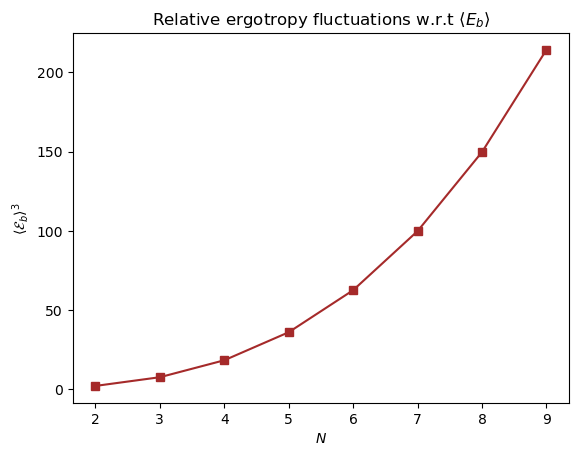

In [6]:
plt.figure()
plt.plot(N_arr, E_momen3, 's-', color='brown')
plt.xlabel(r"$N$")
plt.ylabel(r"$\langle \mathcal{E}_b \rangle^3$")
plt.title(r"Relative ergotropy fluctuations w.r.t $\langle E_b \rangle$")
plt.show()

In [7]:
# =========================
# Check ground state of HB
# =========================

evals, evecs = HB.eigenstates()

psi0_all = qt.tensor([qt.basis(2,0) for _ in range(N)])  # |0...0>
psi1_all = qt.tensor([qt.basis(2,1) for _ in range(N)])  # |1...1>

E0 = qt.expect(HB, psi0_all)
E1 = qt.expect(HB, psi1_all)

print(f"\nN = {N}")
print(f"Ground energy (from diagonalization): {evals[0]:.4f}")
print(f"Energy of |0...0>: {E0:.4f}")
print(f"Energy of |1...1>: {E1:.4f}")

print("Is |0...0> ground state?", np.isclose(E0, evals[0]))
print("Is |1...1> ground state?", np.isclose(E1, evals[0]))


N = 9
Ground energy (from diagonalization): 0.0000
Energy of |0...0>: 9.0000
Energy of |1...1>: 0.0000
Is |0...0> ground state? False
Is |1...1> ground state? True
